<a href="https://colab.research.google.com/github/priyanshukum-array/ML_PROJECTS/blob/main/pneumonia_version1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mt
import seaborn as sns


In [2]:
pip install opendatasets

In [3]:
import opendatasets as od

dataset_url = "https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia"

od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: PriyanshuKumar
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [01:55<00:00, 21.4MB/s]


In [4]:
import tensorflow as tf

In [5]:
#to load data into tensor flow
import os

os.listdir("chest-xray-pneumonia")

['chest_xray']

In [6]:
os.listdir("chest-xray-pneumonia/chest_xray")

['chest_xray', 'train', 'test', '__MACOSX', 'val']

In [7]:
os.listdir("chest-xray-pneumonia/chest_xray/train")

['PNEUMONIA', 'NORMAL']

In [8]:
#as train and test data is already split
train_ds = tf.keras.utils.image_dataset_from_directory(
    "chest-xray-pneumonia/chest_xray/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "chest-xray-pneumonia/chest_xray/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "chest-xray-pneumonia/chest_xray/test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.
Found 624 files belonging to 2 classes.


In [9]:
print(train_ds.class_names)

['NORMAL', 'PNEUMONIA']


In [10]:
#normalizing the image
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [11]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


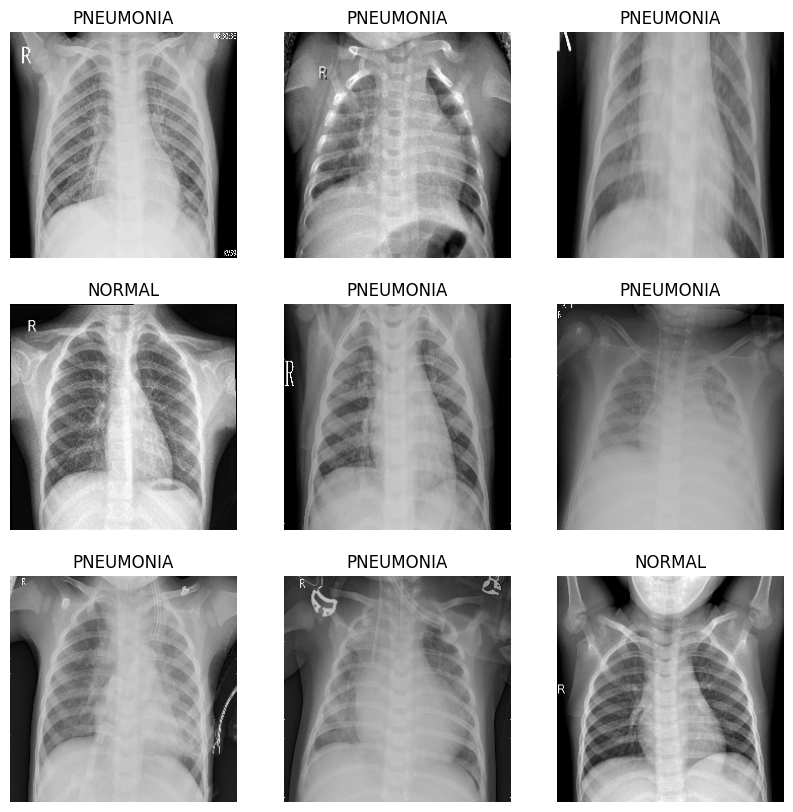

In [12]:
import matplotlib.pyplot as mt

mt.figure(figsize=(10,10))

# Define class_names as it was lost after the .map() operation
class_names = ['NORMAL', 'PNEUMONIA']

for images, labels in train_ds.take(1):
    for i in range(9):
        mt.subplot(3,3,i+1)
        mt.imshow(images[i].numpy(), cmap="gray")
        mt.title(class_names[labels[i]]) # Use the new class_names variable
        mt.axis("off")

In [13]:
#creating the model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

In [14]:
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(224,224,3)
))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(224,224,3)
))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 107, 107, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#TRAINING

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 52s 310ms/step - accuracy: 0.8902 - loss: 0.2646 - val_accuracy: 0.9770 - val_loss: 0.0858
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 223ms/step - accuracy: 0.9504 - loss: 0.1381 - val_accuracy: 0.9741 - val_loss: 0.0668
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 43s 239ms/step - accuracy: 0.9758 - loss: 0.0710 - val_accuracy: 0.9837 - val_loss: 0.0431
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 226ms/step - accuracy: 0.9792 - loss: 0.0554 - val_accuracy: 0.9923 - val_loss: 0.0243
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 39s 300ms/step - accuracy: 0.9842 - loss: 0.0434 - val_accuracy: 0.9674 - val_loss: 0.0910
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 234ms/step - accuracy: 0.9887 - loss: 0.0284 - val_accuracy: 0.9962 - val_loss: 0.0132
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 41s 234ms/step - accuracy: 0.9897 - loss: 0.0277 - val_accuracy: 0.9875 - val_loss: 0.0366
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 224ms/step - accuracy: 0.9914 - loss: 0

In [17]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 207ms/step - accuracy: 0.7837 - loss: 1.6732
Test Loss: 1.6732085943222046
Test Accuracy: 0.7836538553237915


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 107, 107, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)